# 13.4.1 同一均值的不同局部结构

## 学习目标与先修知识

用密度与两点相关（two-point correlation）说明粗粒化（coarse-graining）后的信息损失。

先修：12.5 密度与相关性；13.1 序参量（order parameter）；11.1 网络结构。

## 具体问题

把四个细胞状态（state）压成一个平均密度后，哪些未来结论还能确定？相同平均值是否足以代表相同空间结构？

In [1]:
import math
import random
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager
from systems_science import plot_style, show_table
plot_style()
font_names = {font.name for font in font_manager.fontManager.ttflist}
for name in ("Microsoft YaHei", "SimHei", "Noto Sans CJK SC"):
    if name in font_names:
        plt.rcParams["font.sans-serif"] = [name, "DejaVu Sans"]
        break
BLUE, PINK, GREEN = "#008bfb", "#ff0051", "#00a56a"

## 初步实验

两条四格周期环 1010 与 1100 都有两个激活格。先只看均值作预测，再按左右邻居异或逐格计算下一轮。

In [2]:
a=[1,0,1,0];b=[1,1,0,0]
for state in [a,b]:
    updated=[state[(i-1)%4]^state[(i+1)%4] for i in range(4)]
    print('初态',state,'均值',sum(state)/4,'；下一轮',updated,'均值',sum(updated)/4)

初态 [1, 0, 1, 0] 均值 0.5 ；下一轮 [0, 0, 0, 0] 均值 0.0
初态 [1, 1, 0, 0] 均值 0.5 ；下一轮 [1, 1, 1, 1] 均值 1.0


## 模型假设

沿用第 12 篇采用周期边界（periodic boundary）的二值异或规则，同步读取旧状态。粗变量 p 是当下全环平均；c2 是左右邻居同时为1的两点频率。用这两个统计量（statistic）预测下一步全局密度。

## 数学解释与推导

异或两个二值量满足 $a\oplus b=a+b-2ab$。逐格求和得 $p_{t+1}=2p_t-2c_{2,t}$，其中 $c_{2,t}=N^{-1}\sum_i s_{i-1,t}s_{i+1,t}$。若直接用 $c_2\approx p^2$，便加入了指定位置对独立的平均场闭合（mean-field closure）假设；同 $p$ 不同 $c_2$ 的状态会构成反例。即使 $p,c_2$ 精确封闭这个规则的一步全局平均，也不必封闭每格状态或长期空间统计。

## 核心实现

下面将本节推导写成可运行函数。

In [3]:
def coarse_xor_features(state):
    """Density, distance-two pair frequency, and exact next density on a ring."""
    n = len(state)
    density = sum(state) / n
    pair = sum(state[(i - 1) % n] * state[(i + 1) % n] for i in range(n)) / n
    return [density, pair, 2 * density - 2 * pair]

## 对照实验

将交错与成团初态并列，比较只用均值的独立近似和含两点相关的精确一步预测（one-step-ahead prediction）。

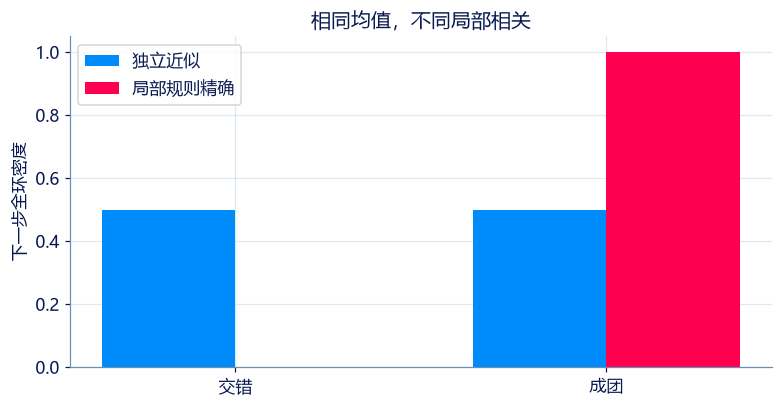

初态 / p / c₂ / 平均场 / 精确： [('交错', 0.5, 0.5, 0.5, 0.0), ('成团', 0.5, 0.0, 0.5, 1.0)]


In [4]:
states={'交错':[1,0,1,0],'成团':[1,1,0,0]}
rows=[]
for name,state in states.items():
    p,c2,actual=coarse_xor_features(state)
    rows.append((name,p,c2,2*p*(1-p),actual))
fig,ax=plt.subplots(figsize=(7,3.6));x=np.arange(2)
ax.bar(x-.18,[row[3] for row in rows],width=.36,label='独立近似',color=BLUE)
ax.bar(x+.18,[row[4] for row in rows],width=.36,label='局部规则精确',color=PINK)
ax.set(xticks=x,xticklabels=[row[0] for row in rows],ylim=(0,1.05),ylabel='下一步全环密度',title='相同均值，不同局部相关')
ax.legend();plt.show()
print('初态 / p / c₂ / 平均场 / 精确：',rows)

## 结果解释

两种排列的 p 相同，却因 c2 不同而有不同下一步。粗粒化保留了指定平均，丢失了局部排列；添加一个相关量能修正该一步指标，却不自动给出完整微观模型（model）。

### 独立核对

枚举所有四格二值环，独立按旧邻居异或核验恒等式。

In [5]:
import itertools
for state in itertools.product([0,1],repeat=4):
    p,c2,pnext=coarse_xor_features(state)
    manual=sum(state[(i-1)%4]^state[(i+1)%4] for i in range(4))/4
    np.testing.assert_allclose(pnext,manual)
assert rows[0][1]==rows[1][1]==.5 and rows[0][4]!=rows[1][4]
print('16种四格状态与同均值反例核对通过。')

16种四格状态与同均值反例核对通过。

## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · Python 计算题：计算粗尺度与局部相关

采用周期边界（periodic boundary）的一维二值环在下一步按左右旧邻居异或同步更新（synchronous update）。返回当前密度 p、左右邻居两点同为1的频率 c2，以及由二者精确得到的下一步密度。

**函数与代码模板**

```python
def solve(
    state: list[int],
) -> list[float]:
    # 按题意计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `state` | `list[int]` | 至少4格、采用周期边界的二值状态（state）。 | 类别 |

**返回值**

直接返回 features（list[float]）。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `features` | `list[float]` | 依次为 p、c2 和下一步密度。 | 无量纲 |

**计算规则**

c2=(1/n)Σ_i state[(i-1)%n]*state[(i+1)%n]；下一步密度=2p-2c2。

**约束与边界**

- 所有比较使用题定模型（model）和相同单位；仅输出（output）函数返回值，不依赖外部文件。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| state | 至少4格、采用周期边界的二值状态（state）。 | [1, 0, 1, 0] | 类别 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
state = [1, 0, 1, 0]

result = solve(state)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| features | 依次为 p、c2 和下一步密度。 | [0.5, 0.5, 0.0] | 无量纲 |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = [0.5, 0.5, 0.0]
```

**样例解释**

两个四格初态密度同为0.5，但距离两格的相关量不同；仅看均值无法预测下一步。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：计算粗尺度与局部相关](http://127.0.0.1:8000/chapters/13-04-%E5%A4%9A%E5%B0%BA%E5%BA%A6%E3%80%81%E7%B2%97%E7%B2%92%E5%8C%96%E4%B8%8E%E4%B8%8D%E7%A1%AE%E5%AE%9A%E6%80%A7/practice/?question=p13-coarse-xor)

### 第 2 题 · 单项选择题：相同均值并不封闭

二值环 1010 与 1100 的平均密度都为0.5，但局部异或下一步不同。遗漏了什么？

- **A.** 局部排列或两点相关（two-point correlation）信息。
- **B.** 平均密度的单位。
- **C.** Python 随机种子（random seed）。
- **D.** 序参量（order parameter）必须改成负数。

[作答：相同均值并不封闭](http://127.0.0.1:8000/chapters/13-04-%E5%A4%9A%E5%B0%BA%E5%BA%A6%E3%80%81%E7%B2%97%E7%B2%92%E5%8C%96%E4%B8%8E%E4%B8%8D%E7%A1%AE%E5%AE%9A%E6%80%A7/practice/?question=p13-same-average-different-structure)

### 第 3 题 · 单项选择题：粗观测能辨认什么

观测（observation）只记录每轮全环平均密度；两个不同微观排列给出同一当前密度。此刻能识别哪项？

- **A.** 当前平均密度可识别，具体局部排列不可由这一值唯一恢复。
- **B.** 每格状态（state）都已被唯一确定。
- **C.** 未来密度必相同。
- **D.** 粗粒化（coarse-graining）自动减少模型结构（model structure）误差至零。

[作答：粗观测能辨认什么](http://127.0.0.1:8000/chapters/13-04-%E5%A4%9A%E5%B0%BA%E5%BA%A6%E3%80%81%E7%B2%97%E7%B2%92%E5%8C%96%E4%B8%8E%E4%B8%8D%E7%A1%AE%E5%AE%9A%E6%80%A7/practice/?question=p13-scale-identifiability)

### 第 4 题 · 单项选择题：相关量也有边界

对本节特定异或规则，p 与 c2 足以给出下一步全局密度。可以推出什么？

- **A.** 这是针对该规则和该一步指标的精确闭合，不保证完整空间状态（state）闭合。
- **B.** p 与 c2 决定任意规则下每格未来状态。
- **C.** 只要有两点相关（two-point correlation）就已证明生物机制。
- **D.** 此规则的边界条件不再重要。

[作答：相关量也有边界](http://127.0.0.1:8000/chapters/13-04-%E5%A4%9A%E5%B0%BA%E5%BA%A6%E3%80%81%E7%B2%97%E7%B2%92%E5%8C%96%E4%B8%8E%E4%B8%8D%E7%A1%AE%E5%AE%9A%E6%80%A7/practice/?question=p13-pair-not-universal)

**进一步阅读**

[SFI Complexity Explorer](https://www.complexityexplorer.org/courses/185-introduction-to-complexity/faq)提供复杂系统与尺度讨论；本节闭合恒等式由题定规则独立推导。